In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('../data/raw/GDP_growth_rate.csv', names=['Date', 'GDP'])

# Preview
print(df.head())


      Date  GDP
0  1997 Q1  1.6
1  1997 Q2  1.1
2  1997 Q3  0.9
3  1997 Q4  1.5
4  1998 Q1  0.7


In [20]:
# Convert to datetime format
def convert_quarter_to_date(quarter_str):
    year, q = quarter_str.split()
    month = {'Q1': '01', 'Q2': '04', 'Q3': '07', 'Q4': '10'}[q]
    return pd.to_datetime(f'{year}-{month}-01')

df['Date'] = df['Date'].apply(convert_quarter_to_date)
df.set_index('Date', inplace=True)


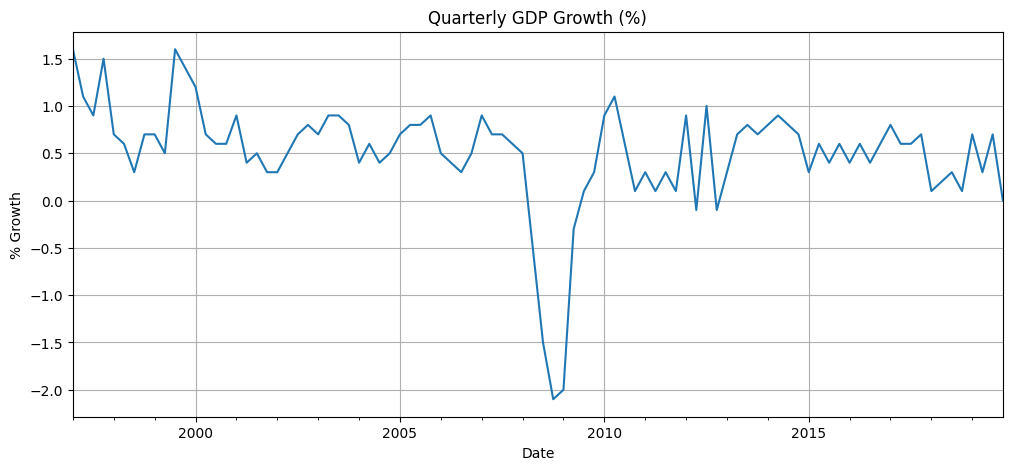

In [21]:
df['GDP'].plot(figsize=(12, 5), title='Quarterly GDP Growth (%)')
plt.ylabel('% Growth')
plt.grid(True)
plt.show()


In [22]:
result = adfuller(df['GDP'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
for key, value in result[4].items():
    print(f'Critical Value ({key}): {value}')


ADF Statistic: -4.406855023567455
p-value: 0.0002886497332453147
Critical Value (1%): -3.506057133647011
Critical Value (5%): -2.8946066061911946
Critical Value (10%): -2.5844100201994697


In [23]:
# 70% train, 30% test
train_size = int(len(df) * 0.70)
train, test = df['GDP'][:train_size], df['GDP'][train_size:]


In [24]:
import warnings
import itertools
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA


warnings.filterwarnings("ignore")


p = range(0, 4)
d = range(0, 3)
q = range(0, 4)
pdq = list(itertools.product(p, d, q))


results = []

for order in pdq:
    try:
        model = ARIMA(df['GDP'], order=order)
        model_fit = model.fit()
        results.append({
            'order': order,
            'aic': model_fit.aic,
            'bic': model_fit.bic
        })
    except:
        continue

# sort the results
results_df = pd.DataFrame(results)
results_df_bic = results_df.sort_values('bic').reset_index(drop=True)
results_df_aic = results_df.sort_values('aic').reset_index(drop=True)

# Show best models
print("Top 5 models based on AIC:")
print(results_df_aic.head())
print("\nTop 5 models based on BIC:")
print(results_df_bic.head())

Top 5 models based on AIC:
       order        aic         bic
0  (3, 0, 0)  97.788872  110.397815
1  (3, 1, 1)  98.993578  111.547876
2  (3, 0, 1)  99.717959  114.848690
3  (1, 0, 2)  99.720562  112.329504
4  (2, 0, 2)  99.845616  114.976347

Top 5 models based on BIC:
       order         aic         bic
0  (1, 0, 0)  102.542849  110.108215
1  (3, 0, 0)   97.788872  110.397815
2  (3, 1, 1)   98.993578  111.547876
3  (1, 0, 2)   99.720562  112.329504
4  (0, 1, 0)  110.530344  113.041204


In [26]:
model = ARIMA(train, order=(3,0,0))  # Best order
model_fit = model.fit()
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                    GDP   No. Observations:                   64
Model:                 ARIMA(3, 0, 0)   Log Likelihood                 -37.561
Date:                Wed, 30 Apr 2025   AIC                             85.122
Time:                        16:49:28   BIC                             95.916
Sample:                    01-01-1997   HQIC                            89.374
                         - 10-01-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5098      0.155      3.299      0.001       0.207       0.813
ar.L1          0.7166      0.094      7.587      0.000       0.531       0.902
ar.L2          0.2665      0.139      1.913      0.0

In [14]:
forecast = model_fit.forecast(steps=len(test))
forecast = pd.Series(forecast, index=test.index)


# Evaluate
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
r2 = r2_score(test, forecast)

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R²: {r2:.4f}')


MAE: 0.2337
RMSE: 0.2717
R²: -0.2508


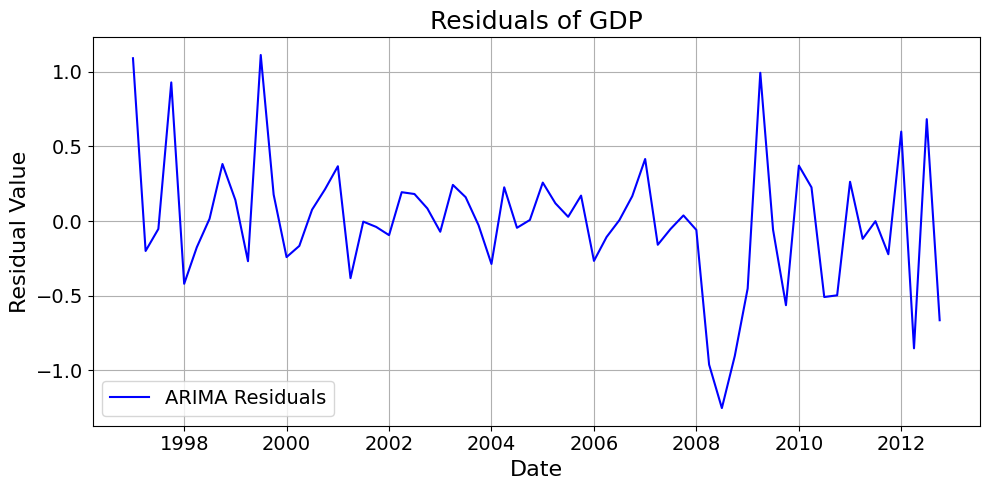

<Figure size 1000x600 with 0 Axes>

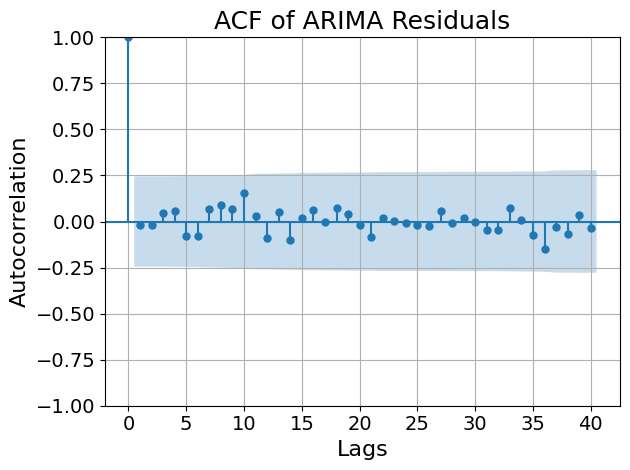

<Figure size 1000x600 with 0 Axes>

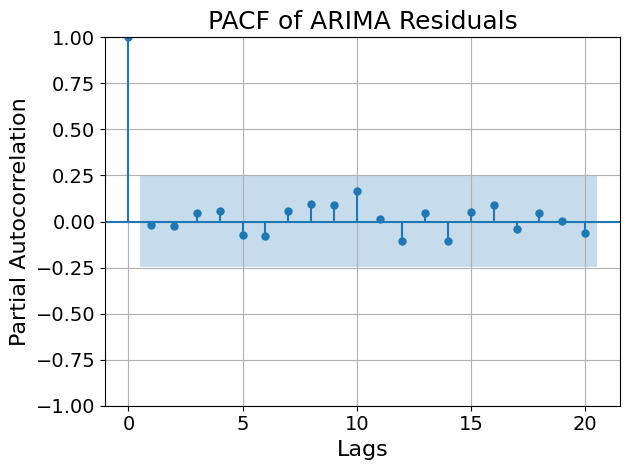

In [27]:
# Residuals from final model
residuals = model_fit.resid

# Plot residuals
plt.figure(figsize=(10, 5))
plt.plot(residuals, label='ARIMA Residuals', color='blue')
plt.title("Residuals of GDP", fontsize=18)
plt.xlabel("Date", fontsize=16)
plt.ylabel("Residual Value", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()


from statsmodels.graphics.tsaplots import plot_acf


plt.figure(figsize=(10, 6))
plot_acf(residuals, lags=40)
plt.title("ACF of ARIMA Residuals", fontsize=18)
plt.xlabel("Lags", fontsize=16)
plt.ylabel("Autocorrelation", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(10, 6))
plot_pacf(residuals, lags=20)
plt.title("PACF of ARIMA Residuals", fontsize=18)
plt.xlabel("Lags", fontsize=16)
plt.ylabel("Partial Autocorrelation", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


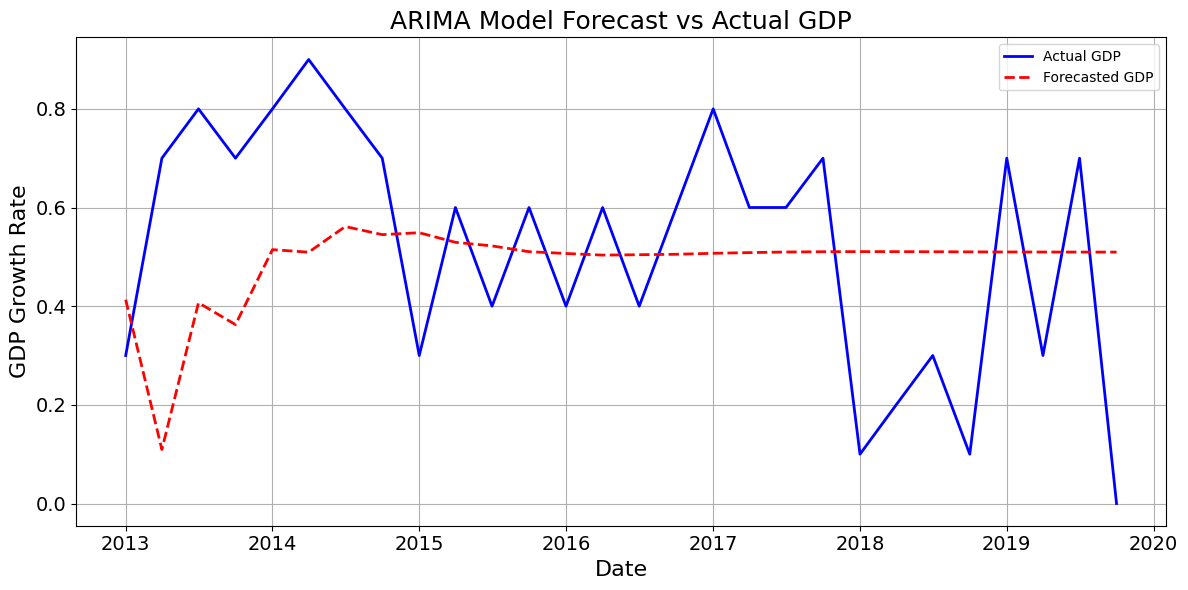

In [16]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))
plt.plot(test.index, test.values, label='Actual GDP', color='blue', linewidth=2)
plt.plot(forecast.index, forecast.values, label='Forecasted GDP', color='red', linestyle='--', linewidth=2)

plt.title('ARIMA Model Forecast vs Actual GDP', fontsize=18)
plt.xlabel('Date', fontsize=16)
plt.ylabel('GDP Growth Rate', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [17]:
# Save results for comparison
arima_forecast_df = pd.DataFrame({
    'Date': test.index,
    'Actual_GDP': test.values,
    'ARIMA_Forecast': forecast.values
})

# Save to CSV
#arima_forecast_df.to_csv('arima_forecast_results.csv', index=False)